## TP5 - Michel Jean Joseph Donnet

In [294]:
## imports
import csv
import numpy as np
import matplotlib.pyplot as plt

### PART 1 - Monday, November 14, 2022

In [295]:
with open('data/X.dat', newline='') as f:
    reader = csv.reader(f, quoting=csv.QUOTE_NONNUMERIC)
    X_dat = list(reader)
with open('data/Y.dat', newline='') as f:
    reader = csv.reader(f, quoting=csv.QUOTE_NONNUMERIC)
    Y_dat = list(reader)

## 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
X = np.array(X_dat).reshape(200, 400)
## list of 200 labels, label for each image, 1 if image is '2' and 0 if image is '3'
y_k = [y[0] for y in Y_dat]

In [296]:
## NOTE : HELPER FUNCTION, IF NEEDED
# Checks if all elements of a list are equal
def checkEqual(lst):
    '''
    checks if all elements of a list are equal
    (by checking if the count of the first element is equal to the list length)

    Parameters:
    -----------
    lst : list of x elements

    Returns:
    --------
    True if all x elements of the list are equal, and False otherwise
    '''
    return lst.count(lst[0]) == len(lst)

In [314]:
# Sigmoidal function
def fun_sigmoid(x):
    # TODO
    '''
    compute sigmoid of value x

    Parameters:
    -----------
    x : scalar value

    Returns:
    --------
    sigmoid(x)
    '''
    return 1.0 / (1.0 + np.exp(-x))


# Calculate h-w1-w2
def h12(pso, X):
    # TODO
    '''
    calculate state of activation of the output layer of neurons (list of 200 values, a value for each image)

    Parameters:
    -----------
    pso : position vector of one particle
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image

    Returns:
    --------
    h : list of 200 values representing the state of activation of the output layer of neurons
    '''
    # w2 matrix, (1, 26) of last 26 elements of pso
    # TODO
    w2 = pso[-26:].reshape(1, 26).astype(float)

    # w1 matrix (25, 401) of first 25*401 elements of pso
    # TODO
    w1 = pso[:-26].reshape(25, 401).astype(float)

    # results' list containing h value for each image
    results = []
    # for every image x
    for x in X:
        # get image (& copy !!)
        # TODO
        img = x.copy()
        # add 1 at 0-position
        # TODO
        img = np.concat([[1.0], img]).astype(float)
        # reshape
        # TODO
        img = img.reshape(-1, 1)
        # calculate c = matrix multiplication of weight matrix 1 and image vector(with 1 at position 0)
        # TODO
        c = w1 @ img
        # apply sigmoidal function on elements of c
        # TODO
        c = fun_sigmoid(c)
        # add 1 at 0-position
        # TODO
        c = np.concat([[1.0], c.ravel()]).astype(float)
        # reshape
        # TODO
        c = c.reshape(26, 1)
        # calculate matrix multiplication of weight matrix 2 and vector z(with 1 at position 0), answer is scalar
        # TODO
        scalar = (w2 @ c)[0, 0]
        # apply sigmoidal fucntion on answer
        # TODO
        scalar = fun_sigmoid(scalar)
        # results, append all h12 for all images
        # TODO
        results.append(scalar)

    return results


# Calculate overall fitness J
def calculate_J(h, y_k):
    # TODO
    '''
    calculate overall fitness J (equation #5 in TP PDF)

    Parameters:
    -----------
    h : list of 200 values representing the state of activation of the output layer of neurons
    y_k : list of 200 labels '1' or '0', for each image

    Returns:
    --------
    fitness_J : overall fitness, mean of all J for each image
    '''
    return np.mean((np.array(y_k).astype(float) - h)**2)

# prediction accuracy of images
def pred_acc(h, X, y_k):
    # TODO
    '''
    calculate the prediction accuracy (%) by comparing prediction & true labels
    y_p (predicted label) = 1 if h>=0.5 & 0 otherwise

    Parameters:
    -----------
    h : list of 200 values representing the state of activation of the output layer of neurons (to be used for best h12)
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
    y_k : list of 200 labels '1' or '0', for each image

    Returns:
    --------
    acc : prediction accuracy
    '''

    # get predicted labels
    # TODO
    y_p = np.ones_like(y_k)
    y_p[h < 0.5] = 0
    # get prediction accuracy (%)
    # TODO
    return (1 / y_k.shape[0]) * np.sum(np.abs(y_k - y_p))


In [320]:
# Algorithm, and training the network
def pso_NN(X, y_k, N, vmax_coeff):
    # TODO
    '''
    perfom PSO algorithm with NN training

    Parameters:
    -----------
    X : 2D array of shape (200, 400), each row (image) contains the 400 grey values of each image
    y_k : list of 200 labels '1' or '0', for each image
    N : number of particles
    vmax_coeff : velocity cutoff coefficient (% of coordinates range, for eg: vmax_coeff=0.1 means vmax=0.1*(xmax_coordinate-xmin_coordinate))

    Returns:
    --------
    J_g : global best fitness
    b_g : global best position
    h_g : global best state activation of output neurons (needed later for prediction)
    J_global : list of all global best positions (for each iteration, needed to plot later on)
    '''
    ## Fixed Parameters
    # cognitive & social parameters
    c1 = c2 = 2
    # inertia constant
    w = 0.9
    # number of coefficients 'n' of weight matrices 1 & 2, combined (go back to h12 function for a reminder if needed)
    n = 401 * 25 + 26
    
    ## Variate Parameters
    # coordinates' range
    c_range = [-1, 1] # or [-0.5, 0.5]
    # velocity threshold vmax = vmax_coeff*(c_max - c_min)
    # TODO
    vmax = vmax_coeff*(np.max(c_range) - np.min(c_range))

    ## NOTE : STOPPING CONDITION
    # choose one of these two stopping conditions: 
    # 1. number of iterations, tmax=?
    # 2. last _ fitness values are equal (or not improving?)
    
    ## Initialize
    # initialize 's' : np array of size (N=number of particles, n=number of coefficients of weight matrices 1&2) with values from coefficients ranging in c_range
    # TODO
    s = np.random.uniform(low=c_range[0], high=c_range[1], size=(N, n))
    # initialize 'v' : np array of size(N, n) of velocity vectors of values 0
    # TODO
    v = np.zeros_like(s)
    
    ## Compute Initial J
    # Compute h12 for all pso in s
    # TODO
    h12_list = np.array([h12(pso, X) for pso in s])
    # compute and save J for all particles
    # TODO
    J_list = np.array([calculate_J(h, y_k) for h in h12_list])
    # get minimum J, and idx (index of minimum)
    # TODO
    idx = np.argmin(J_list)
    J_min = J_list[idx]
    # set local & global J (local J is best J for each particle, global J is best overall J)
    # TODO
    J_g = J_min
    J_global = [J_min]
    J_local = J_list.copy()
    # set local & global positions (local position is best b for each particle, global position is best overall b)
    b_g = s[idx].copy()
    b_local = s.copy()
    # TODO (don't forget to copy if needed !)
    # save minimum h12
    # TODO
    h_g = h12_list[idx]
    
    ## Run algorithm

    # STOPPING CONDITION
    # TODO
    t = 0
    tmax = 200
    while(t < tmax):
        ## For every particle position in s:
        for i in range(s.shape[0]):
            # r1, r2 random numbers between 0 & 1
            r1, r2 = np.random.uniform(low=0, high=1, size=2)
            # Update v
            v[i] = (w * v[i]
                 + c1 * r1 * (b_local[i] - s[i])
                 + c2 * r2 * (b_g - s[i])
            )
            # Check velocity if crossing upper/lower threshold
            v[i] = np.clip(v[i], min=-vmax, max=vmax)
            # Update position
            s[i] += v[i]
            # Check boundary condition & decide what to do if a particle crosses a boundary, some options are:
                # set crossing position to the boundary position
                # reflect crossing position
                # bounce-back crossing position
            bound_length = c_range[1] - c_range[0]
            # s[i] += c_range[0]
            # s[i] %= bound_length
            # s[i] -= c_range[0]
            s[i] = np.clip(s[i], min=c_range[0], max=c_range[1])
            # Calculate new J (by first calculating h12)
            h12_list[i] = h12(s[i], X)
            J_list[i] = calculate_J(h12_list[i], y_k)
            # Check if found new best fitness, set to local fitness
            if J_list[i] < J_local[i]:
                J_local[i] = J_list[i]
                b_local[i] = s[i].copy()
        # Get minimum of all new best J, if best is < global J, set to global J
        idx = np.argmin(J_local)
        if J_local[idx] < J_g:
            J_g = J_local[idx]
            b_g = s[idx].copy()
            # save best h12
            h_g = h12_list[idx].copy()
        J_global.append(J_g)
        t += 1
        # Update if Stopping Condition #2

    return J_g, b_g, h_g, J_global

0.022509517622696616
[np.float64(0.24336185848871458), np.float64(0.24336185848871458), np.float64(0.23698711066145708), np.float64(0.1937939694290186), np.float64(0.17493189796649716), np.float64(0.14967544258752052), np.float64(0.14967544258752052), np.float64(0.14543366381399242), np.float64(0.13291201139928263), np.float64(0.12703831149568565), np.float64(0.1256642208443565), np.float64(0.11417062745111745), np.float64(0.10676072525247068), np.float64(0.09944333410874616), np.float64(0.09547670898382707), np.float64(0.09186777877519652), np.float64(0.09117825078610661), np.float64(0.08754925028594322), np.float64(0.08754925028594322), np.float64(0.08703732860479661), np.float64(0.0866059645463039), np.float64(0.08501194016868721), np.float64(0.08501194016868721), np.float64(0.0843757621117351), np.float64(0.0843757621117351), np.float64(0.0843757621117351), np.float64(0.08406735535160713), np.float64(0.08377432115582824), np.float64(0.07970050528818852), np.float64(0.07929343865323

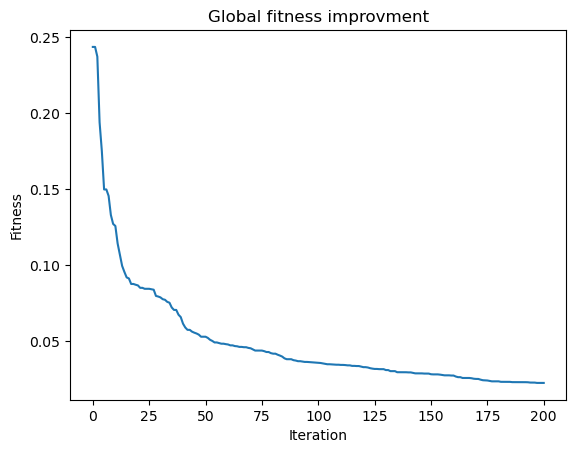

In [321]:
# Test run pso_NN function for N=10 & vmax_coeff=0.1, and get prediction accuracy
# TODO
J_g, b_g, h_g, J_global = pso_NN(X, y_k, 10, 0.1)
print(J_g)
print(J_global)
plt.figure()
plt.plot(np.arange(len(J_global)), J_global)
plt.title("Global fitness improvment")
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.show()

### PART 2 - Monday, November 21, 2022

In [300]:
# Run algorithm for range of N, & plot best_fitness vs N (set vmax_coeff=0.1)
N = [10, 20, 30, 50]

### How does the number of particles affect the result of the PSO algorithm?

In [301]:
# Run algorithm for range of vmax_coeff, the cutoff velocity coefficient (choose N according to experiment above)
vmax_coeff = [0, 0.1, 0.2, 0.3]

### How does the velocity cut-off $v_{max}$ affect the result of the PSO algorithm?

In [302]:
# Run algorithm 10 times, noting the prediction accuracy (or error) for each run 
# TODO

In [303]:
# Plot the best_fitness of each run vs. the number of iterations it took (in case of stop condition #2)
# TODO

In [304]:
# For one of the 10 runs (choose the one with the best fitness), plot J(w1, w2) as a function of the iteration number
# TODO

### Comment on your results

Answer the following Questions: 

1.  Q: What is the Search Space of our problem?

    A: 


2.  Q: Explain the coefficients c1 & c2

    A:
    

3.  Q: How is PSO similar to Ant Algorithm?

    A:
